# IBL post-clustering waveform audit

This notebook applies the same post-clustering SPN–FSI validation used in Notebook 07 to the retained units from the IBL dataset.

> Run this notebook after Notebook 05 and before Notebook 09. It writes unit-level audit annotations only. It does not rerun clustering or change any saved subtype label. Notebook 09 applies the audit to the fixed labels.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from one.api import ONE

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

ROOT = PROJECT_ROOT

import warnings
from one.alf.exceptions import ALFWarning
warnings.filterwarnings("ignore", category=ALFWarning, message="Multiple revisions.*")

from spn_figures.config import SPN_COLORS
from spn_figures.waveform_validation import (
    FSI_HALF_WIDTH_MS,
    FSI_RATE_HZ,
    add_operational_classification,
    audit_summary,
    measure_trough_half_width,
    select_peak_channel_waveform,
)

pd.set_option("display.max_columns", 50)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 13,  
    "axes.titlesize": 14,   
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
    "axes.labelpad": 4,
    "axes.titlepad": 9,
    "xtick.major.pad": 2,
    "ytick.major.pad": 2,
})

## Configuration and retained-unit table

In [2]:
LABEL_PATH = ROOT / "data" / "derived" / "ibl" / "unit_labels.csv"
PROFILE_PATH = ROOT / "data" / "derived" / "ibl" / "unit_profiles.csv.gz"
OUTPUT_CSV = ROOT / "data" / "derived" / "ibl" / "postclustering_spn_fsi_waveform_audit.csv"
FIGURE_DIR = ROOT / "figures" / "supporting"
FIGURE_STEM = FIGURE_DIR / "FigSY_ibl_postclustering_spn_fsi_waveform_audit"
CACHE_DIR = ROOT / "data" / "source" / "ibl_one_cache"

SORTER = "pykilosort"
REVISION = "2024-05-06"
SAMPLE_RATE_HZ = 30_000.0
BASELINE_EDGE_SAMPLES = 6

required_label_columns = {
    "session", "eid", "pid", "probe", "unit_id", "final_label", "final_name"
}
labels_all = pd.read_csv(LABEL_PATH)

labels = labels_all.loc[
    (pd.to_numeric(labels_all["final_label"], errors="coerce") >= 0)
    & labels_all["final_name"].notna()
    & labels_all["final_name"].ne("unassigned")
].copy()
labels["unit_id"] = labels["unit_id"].astype(int)

display(labels.groupby(["session", "final_name"]).size().unstack(fill_value=0))

final_name,dSPN_left,dSPN_right,iSPN_left,iSPN_right
session,,,,
churchlandlab | CSHL049 | 2020-01-08,9,4,8,3
cortexlab | KS086 | 2022-03-16,5,3,4,11
danlab | DY_014 | 2020-07-18,4,7,7,11
hoferlab | SWC_061 | 2020-11-23,9,3,8,4
mrsicflogellab | SWC_038 | 2020-07-31,3,3,5,5
mrsicflogellab | SWC_038 | 2020-08-01,3,26,3,3
zadorlab | CSH_ZAD_026 | 2020-08-17,13,3,3,10


## Download exact cluster objects and measure retained units

The IBL arrays have `(clusters, 82 samples, 32 channels)` waveforms.
`clusters.metrics.cluster_id` is explicitly mapped to array rows.

In [3]:
CACHE_DIR.mkdir(parents=True, exist_ok=True)
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    cache_dir=CACHE_DIR,
    password="international",
    silent=True,
)

rows: list[dict[str, object]] = []
waveform_rows: list[dict[str, object]] = []

for pid, selected in labels.groupby("pid", sort=False):
    eid = str(selected["eid"].iloc[0])
    probe = str(selected["probe"].iloc[0])
    collection = f"alf/{probe}/{SORTER}"
    clusters = one.load_object(
        eid,
        "clusters",
        collection=collection,
        revision=REVISION,
        attribute=["waveforms", "waveformsChannels", "channels", "metrics", "peakToTrough"],
    )

    required_objects = {"waveforms", "waveformsChannels", "channels", "metrics", "peakToTrough"}
    missing_objects = required_objects.difference(clusters.keys())
    if missing_objects:
        raise KeyError(f"{pid}: missing IBL cluster objects {sorted(missing_objects)}")

    waveforms = np.asarray(clusters["waveforms"])
    waveform_channels = np.asarray(clusters["waveformsChannels"])
    peak_channels = np.asarray(clusters["channels"]).reshape(-1)
    source_peak_to_trough = np.asarray(clusters["peakToTrough"], dtype=float).reshape(-1)
    metrics = clusters["metrics"].copy()

    n_clusters = waveforms.shape[0]
    metric_ids = pd.to_numeric(metrics["cluster_id"], errors="raise").astype(int).to_numpy()
    row_by_cluster_id = {int(cluster_id): int(row) for row, cluster_id in enumerate(metric_ids)}
    selected_ids = selected["unit_id"].to_numpy(int)

    for label in selected.itertuples(index=False):
        unit_id = int(label.unit_id)
        cluster_row = row_by_cluster_id[unit_id]
        waveform, waveform_column, selection_method = select_peak_channel_waveform(
            waveforms[cluster_row],
            waveform_channels[cluster_row],
            int(peak_channels[cluster_row]),
        )
        measurement = measure_trough_half_width(
            waveform,
            sample_rate_hz=SAMPLE_RATE_HZ,
            baseline_edge_samples=BASELINE_EDGE_SAMPLES,
        )
        session_rate_hz = float(metrics.iloc[cluster_row]["firing_rate"])

        row = label._asdict()
        row.update(measurement)
        row.update(
            {
                "data_source": "IBL",
                "sorter": SORTER,
                "revision": REVISION,
                "collection": collection,
                "cluster_array_row": cluster_row,
                "sample_rate_hz": SAMPLE_RATE_HZ,
                "peak_channel": int(peak_channels[cluster_row]),
                "waveform_column": int(waveform_column),
                "channel_selection": selection_method,
                "n_session_spikes": int(metrics.iloc[cluster_row]["spike_count"]),
                "session_rate_hz": session_rate_hz,
                "source_trough_to_peak_ms": float(source_peak_to_trough[cluster_row]),
            }
        )
        rows.append(row)
        waveform_rows.append(
            {
                "pid": pid,
                "unit_id": unit_id,
                "waveform": waveform,
                "trough_index": int(measurement["trough_index"]),
                "baseline": float(measurement["baseline"]),
                "width_valid": bool(measurement["width_valid"]),
            }
        )

audit = add_operational_classification(pd.DataFrame(rows))

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
audit.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(audit)} unit-level rows to {OUTPUT_CSV.relative_to(ROOT)}")

(S3) /Users/zhuojunyu/Desktop/CBGTPy_control/All_GitHub_Code_NEW/data/source/ibl_one_cache/churchlandlab/Subjects/CSHL049/2020-01-08/001/alf/probe01/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 6.62k/6.62k [00:00<00:00, 62.8kB/s]
(S3) /Users/zhuojunyu/Desktop/CBGTPy_control/All_GitHub_Code_NEW/data/source/ibl_one_cache/churchlandlab/Subjects/CSHL049/2020-01-08/001/alf/probe01/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 114k/114k [00:00<00:00, 581kB/s]
(S3) /Users/zhuojunyu/Desktop/CBGTPy_control/All_GitHub_Code_NEW/data/source/ibl_one_cache/churchlandlab/Subjects/CSHL049/2020-01-08/001/alf/probe01/pykilosort/#2024-05-06#/clusters.peakToTrough.npy: 100%|██████████| 6.62k/6.62k [00:00<00:00, 64.2kB/s]
(S3) /Users/zhuojunyu/Desktop/CBGTPy_control/All_GitHub_Code_NEW/data/source/ibl_one_cache/churchlandlab/Subjects/CSHL049/2020-01-08/001/alf/probe01/pykilosort/#2024-05-06#/clusters.waveforms.npy: 100%|██████████| 8.51M/8.51M [00:00<00:00, 20.1MB/s]
(S3

Saved 180 unit-level rows to data/derived/ibl/postclustering_spn_fsi_waveform_audit.csv


## Coverage, classification summary, and mapping checks

In [4]:
overall = audit_summary(audit)
by_subtype = audit_summary(audit, ["final_name"])
by_session = audit_summary(audit, ["session"])
display(overall)
display(by_subtype)
display(by_session)

print("Channel selection:")
display(audit["channel_selection"].value_counts(dropna=False).rename("n_units").to_frame())
print("Waveform QC:")
display(audit.groupby(["qc_status", "qc_warning"], dropna=False).size().rename("n_units").to_frame())

mapping_qc = audit.loc[
    audit["width_valid"]
    & np.isfinite(audit["source_trough_to_peak_ms"])
    & (audit["source_trough_to_peak_ms"] > 0)
    & np.isfinite(audit["trough_to_later_peak_ms"]),
    ["source_trough_to_peak_ms", "trough_to_later_peak_ms"],
]
if len(mapping_qc) >= 3:
    mapping_r = float(mapping_qc.corr().iloc[0, 1])
    print(f"QC correlation with source trough-to-peak duration: r = {mapping_r:.3f} (n={len(mapping_qc)})")
else:
    print("Source trough-to-peak duration unavailable for a correlation check.")

,n_retained_units,n_valid_for_joint_screen,coverage,n_strongly_fsi_like,n_not_strongly_fsi_like,fraction_not_strongly_fsi_like,wilson95_low,wilson95_high
0,180,180,1.0,21,159,0.883333,0.828232,0.922414


,final_name,n_retained_units,n_valid_for_joint_screen,coverage,n_strongly_fsi_like,n_not_strongly_fsi_like,fraction_not_strongly_fsi_like,wilson95_low,wilson95_high
0,dSPN_right,49,49,1.0,4,45,0.918367,0.808109,0.967797
1,iSPN_right,47,47,1.0,8,39,0.829787,0.698602,0.911136
2,iSPN_left,38,38,1.0,3,35,0.921053,0.792006,0.972785
3,dSPN_left,46,46,1.0,6,40,0.869565,0.743341,0.938822


,session,n_retained_units,n_valid_for_joint_screen,coverage,n_strongly_fsi_like,n_not_strongly_fsi_like,fraction_not_strongly_fsi_like,wilson95_low,wilson95_high
0,churchlandlab | CSHL049 | 2020-01-08,24,24,1.0,12,12,0.500000,0.314274,0.685726
1,zadorlab | CSH_ZAD_026 | 2020-08-17,29,29,1.0,3,26,0.896552,0.736149,0.964185
2,danlab | DY_014 | 2020-07-18,29,29,1.0,2,27,0.931034,0.780354,0.980879
3,hoferlab | SWC_061 | 2020-11-23,24,24,1.0,0,24,1.000000,0.862024,1.000000
4,mrsicflogellab | SWC_038 | 2020-08-01,35,35,1.0,0,35,1.000000,0.901099,1.000000
5,mrsicflogellab | SWC_038 | 2020-07-31,16,16,1.0,0,16,1.000000,0.806392,1.000000
6,cortexlab | KS086 | 2022-03-16,23,23,1.0,4,19,0.826087,0.628624,0.930213


Channel selection:


,n_units
channel_selection,
reported_peak_channel,180


Waveform QC:


n_units
qc_status qc_warning                        
ok                                       172
          positive_excursion_larger        8

QC correlation with source trough-to-peak duration: r = 0.934 (n=140)


## Supporting-information figure

Panel A shows the actual retained-unit peak-channel templates, baseline
subtracted and normalized to their maximum absolute deflection. 
Panel B shows the trough half-width distribution. 
Panel C shows the joint rule; only the upper-left
shaded quadrant is flagged as putative SPNs.
Panel D compares each original fixed-label subtype-average profile with the
corresponding profile after excluding units flagged as putative FSIs.

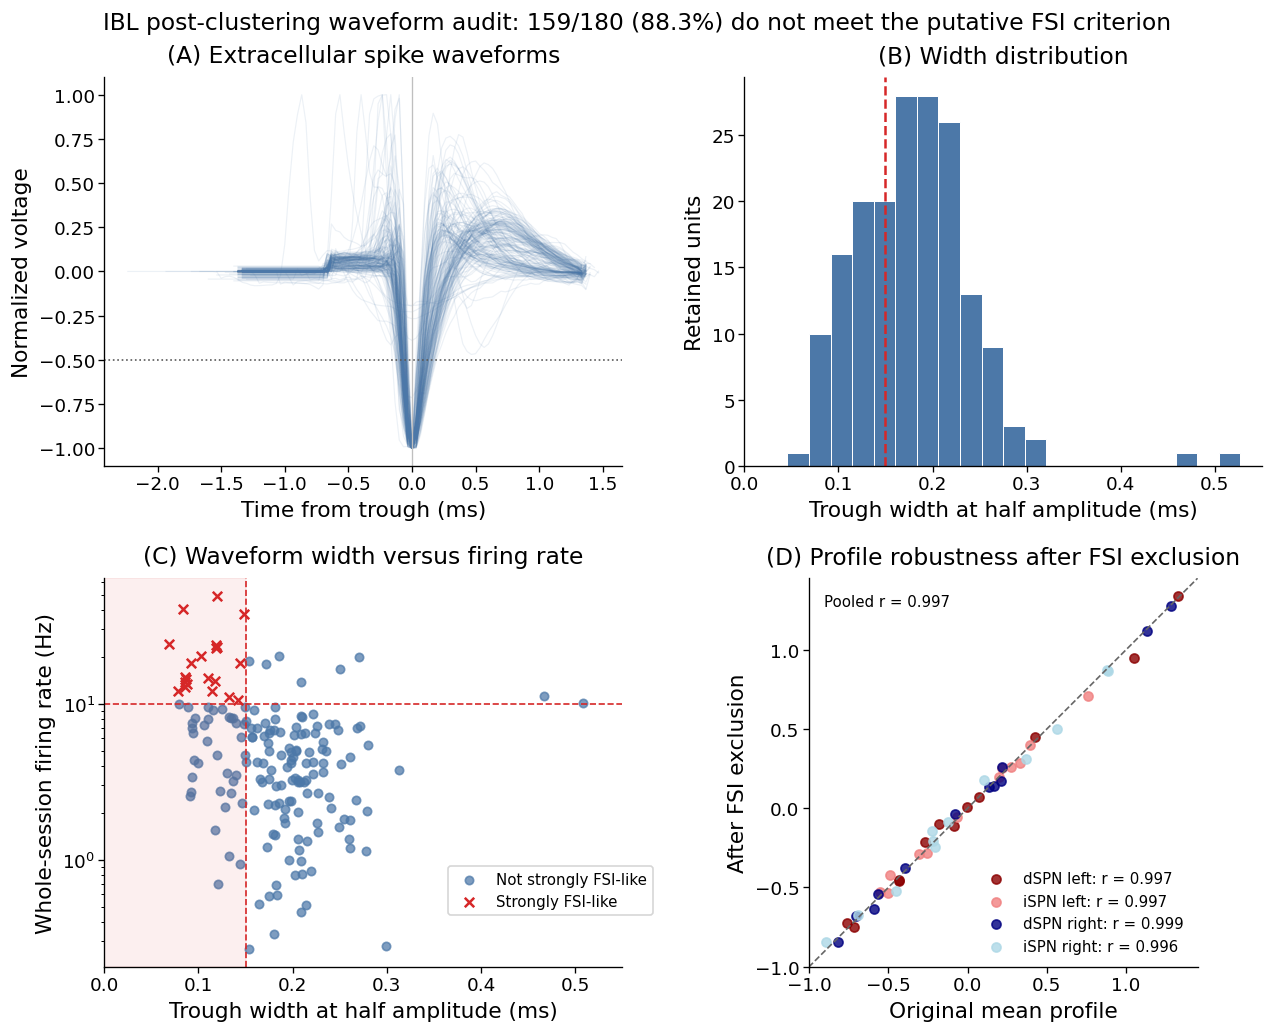

In [5]:
valid_waveforms = [item for item in waveform_rows if item["width_valid"]]
valid = audit.loc[audit["strongly_fsi_like"].notna()].copy()
if valid.empty:
    raise ValueError("No retained units have a valid waveform and firing-rate measurement.")

profiles = pd.read_csv(PROFILE_PATH)
profile_audit = profiles.merge(
    audit[["session", "unit_id", "final_name", "strongly_fsi_like"]],
    on=["session", "unit_id"],
    how="left",
    validate="many_to_one",
)
if profile_audit["final_name"].isna().any():
    raise ValueError("Some saved unit profiles could not be matched to the waveform audit.")
if not profile_audit["spn_name"].eq(profile_audit["final_name"]).all():
    raise ValueError("Saved profile labels do not match the fixed post-clustering labels.")
profile_audit["exclude_as_fsi"] = profile_audit["strongly_fsi_like"].fillna(False).astype(bool)

profile_order = ["dSPN_left", "iSPN_left", "dSPN_right", "iSPN_right"]
profile_index = pd.MultiIndex.from_product(
    [["left", "right"], range(-6, 0)],
    names=["choice_side", "bin_from_decision"],
)
profile_comparison = {}
for name in profile_order:
    subtype = profile_audit.loc[profile_audit["spn_name"].eq(name)]
    original = (
        subtype.groupby(["choice_side", "bin_from_decision"])["z_rate"]
        .mean()
        .reindex(profile_index)
    )
    filtered = (
        subtype.loc[~subtype["exclude_as_fsi"]]
        .groupby(["choice_side", "bin_from_decision"])["z_rate"]
        .mean()
        .reindex(profile_index)
    )
    if original.isna().any() or filtered.isna().any():
        raise ValueError(f"Incomplete original or FSI-filtered profile for {name}.")
    original_values = original.to_numpy(float)
    filtered_values = filtered.to_numpy(float)
    profile_comparison[name] = {
        "original": original_values,
        "filtered": filtered_values,
        "pearson_r": float(np.corrcoef(original_values, filtered_values)[0, 1]),
    }

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5), constrained_layout=True)
fig.get_layout_engine().set(wspace=0.05, hspace=0.05)
axes = axes.ravel()

ax = axes[0]
for item in valid_waveforms:
    y = np.asarray(item["waveform"], float) - float(item["baseline"])
    scale = np.max(np.abs(y))
    if not np.isfinite(scale) or scale <= 0:
        continue
    time_ms = (np.arange(y.size) - int(item["trough_index"])) * 1000.0 / SAMPLE_RATE_HZ
    ax.plot(time_ms, y / scale, color="#4C78A8", alpha=0.10, linewidth=0.7)
ax.axhline(-0.5, color="0.35", linestyle=":", linewidth=1)
ax.axvline(0, color="0.75", linewidth=0.8)
ax.set(xlabel="Time from trough (ms)", ylabel="Normalized voltage", title="(A) Extracellular spike waveforms")

ax = axes[1]
widths = valid["trough_half_width_ms"].to_numpy(float)
upper = max(0.35, min(0.80, float(np.ceil(np.nanpercentile(widths, 99) * 20) / 20)))
bins = np.linspace(0, upper, 25)
ax.hist(widths, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.6)
ax.axvline(FSI_HALF_WIDTH_MS, color="#D62728", linestyle="--", linewidth=1.5, label="FSI screen: 0.15 ms")
ax.set(xlabel="Trough width at half amplitude (ms)", ylabel="Retained units", title="(B) Width distribution", xlim=(0, upper))

ax = axes[2]
fsi = valid["strongly_fsi_like"].astype(bool).to_numpy()
rate_for_plot = np.maximum(valid["session_rate_hz"].to_numpy(float), 0.03)
ax.scatter(valid.loc[~fsi, "trough_half_width_ms"], rate_for_plot[~fsi], s=25, color="#4C78A8", alpha=0.72, label="Not strongly FSI-like")
ax.scatter(valid.loc[fsi, "trough_half_width_ms"], rate_for_plot[fsi], s=32, color="#D62728", marker="x", linewidth=1.5, label="Strongly FSI-like")
ax.axvline(FSI_HALF_WIDTH_MS, color="#D62728", linestyle="--", linewidth=1)
ax.axhline(FSI_RATE_HZ, color="#D62728", linestyle="--", linewidth=1)
ax.axvspan(0, FSI_HALF_WIDTH_MS, color="#D62728", alpha=0.07)
ax.set_yscale("log")
ax.set(xlabel="Trough width at half amplitude (ms)", ylabel="Whole-session firing rate (Hz)", title="(C) Waveform width versus firing rate", xlim=(0, upper))
ax.legend(bbox_to_anchor=(0.65, 0.28))

ax = axes[3]
pooled_original = []
pooled_filtered = []
for name in profile_order:
    comparison = profile_comparison[name]
    pooled_original.append(comparison["original"])
    pooled_filtered.append(comparison["filtered"])
    ax.scatter(
        comparison["original"],
        comparison["filtered"],
        s=30,
        color=SPN_COLORS[name],
        alpha=0.80,
        label=f"{name.replace('_', ' ')}: r = {comparison['pearson_r']:.3f}",
    )
pooled_original = np.concatenate(pooled_original)
pooled_filtered = np.concatenate(pooled_filtered)
pooled_r = float(np.corrcoef(pooled_original, pooled_filtered)[0, 1])
limits = np.array([
    min(pooled_original.min(), pooled_filtered.min()),
    max(pooled_original.max(), pooled_filtered.max()),
])
padding = 0.05 * max(limits[1] - limits[0], 1.0)
limits = limits + np.array([-padding, padding])
ax.plot(limits, limits, color="0.4", linestyle="--", linewidth=1)
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_aspect("equal", adjustable="box")
ax.set(
    xlabel="Original mean profile",
    ylabel="After FSI exclusion",
    title="(D) Profile robustness after FSI exclusion",
)
ax.text(0.04, 0.96, f"Pooled r = {pooled_r:.3f}", transform=ax.transAxes, va="top", fontsize=9)
ax.legend(frameon=False, loc="lower right", fontsize=9)

n_valid = len(valid)
n_not = int((~fsi).sum())
fraction = n_not / n_valid
fig.suptitle(
    f"IBL post-clustering waveform audit: {n_not}/{n_valid} "
    f"({fraction:.1%}) do not meet the putative FSI criterion",
    fontsize=14,
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_STEM.with_suffix(".png"), dpi=300, bbox_inches="tight")
plt.show()